In [2]:
import pandas as pd 
import zipfile

In [3]:
zip_path = '../data/LLCP2024XPT.zip'
file_path = 'LLCP2024.XPT '

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open(file_path) as f:
        df = pd.read_sas(f, format='xport')



In [4]:
df.head(5) 

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_LCSCTSN,_LCSPSTF,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK3,_RFDRHV9,_FLSHOT7,_PNEUMO3,_AIDTST4
0,1.0,2.0,b'02282024',b'02',b'28',b'2024',1100.0,b'2024000001',2.024000e+09,1.0,...,NaN,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,2.0,2.0
1,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000002',2.024000e+09,1.0,...,4.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0
2,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000003',2.024000e+09,1.0,...,4.0,2.0,1.0,1.000000e+02,2.0,1.400000e+03,1.0,NaN,NaN,2.0
3,1.0,2.0,b'02282024',b'02',b'28',b'2024',1100.0,b'2024000004',2.024000e+09,1.0,...,NaN,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0
4,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000005',2.024000e+09,1.0,...,3.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,NaN,NaN,2.0


In [5]:
df.shape

(457670, 301)

## Data Cleaning

In [25]:
df.isna()

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_LCSCTSN,_LCSPSTF,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK3,_RFDRHV9,_FLSHOT7,_PNEUMO3,_AIDTST4
0,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
3,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
457665,False,False,False,False,False,False,False,False,False,True,...,True,True,False,False,False,False,False,False,False,True
457666,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
457667,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
457668,False,False,False,False,False,False,False,False,False,True,...,True,True,False,False,False,False,False,True,True,True


In [20]:
print(df.isna().sum())

_STATE           0
FMONTH           0
IDATE            0
IMONTH           0
IDAY             0
             ...  
_DRNKWK3         0
_RFDRHV9         0
_FLSHOT7    278326
_PNEUMO3    278326
_AIDTST4     43492
Length: 301, dtype: int64


## Correlations

#### NOTES
- target (diabete4 or diabtype)
- does type1 count due to genetics?
- diabage4 (data leak)

In [30]:
# correlation values

corr = df.corr(numeric_only=True)["DIABETE4"].sort_values(ascending=False).head(10)
print(corr, "\n")

corr = df.corr(numeric_only=True)["DIABTYPE"].sort_values(ascending=False).head(10)
print(corr)

DIABETE4    1.000000
_MICHD      0.158626
HAVARTH4    0.152229
_DRDXAR2    0.145814
DIFFWALK    0.144071
RMVTETH4    0.126366
_LCSCTSN    0.126339
CHCKDNY2    0.125817
CVDSTRK3    0.106679
CHECKUP1    0.105660
Name: DIABETE4, dtype: float64 

DIABTYPE    1.000000
HADSEX      0.241819
CASTHNO2    0.182117
CHKHEMO3    0.162385
HPVADVC4    0.146177
DIABAGE4    0.134841
TETANUS1    0.130550
CSRVSUM     0.130255
CNCRTYP2    0.123294
NOBCUSE8    0.119229
Name: DIABTYPE, dtype: float64


In [31]:
# columns (DIABTYPE)
#col = ['HADSEX', 'CASTHNO2', 'CHKHEMO3', 'HPVADVC4', 'DIABAGE4', 'TETANUS1', 'CSRVSUM']

# diabete4
col = ['_MICHD', 'HAVARTH4', 'DIFFWALK', 'RMVTETH4', '_LCSCTSN', 'CHCKDNY2']

## Distributions

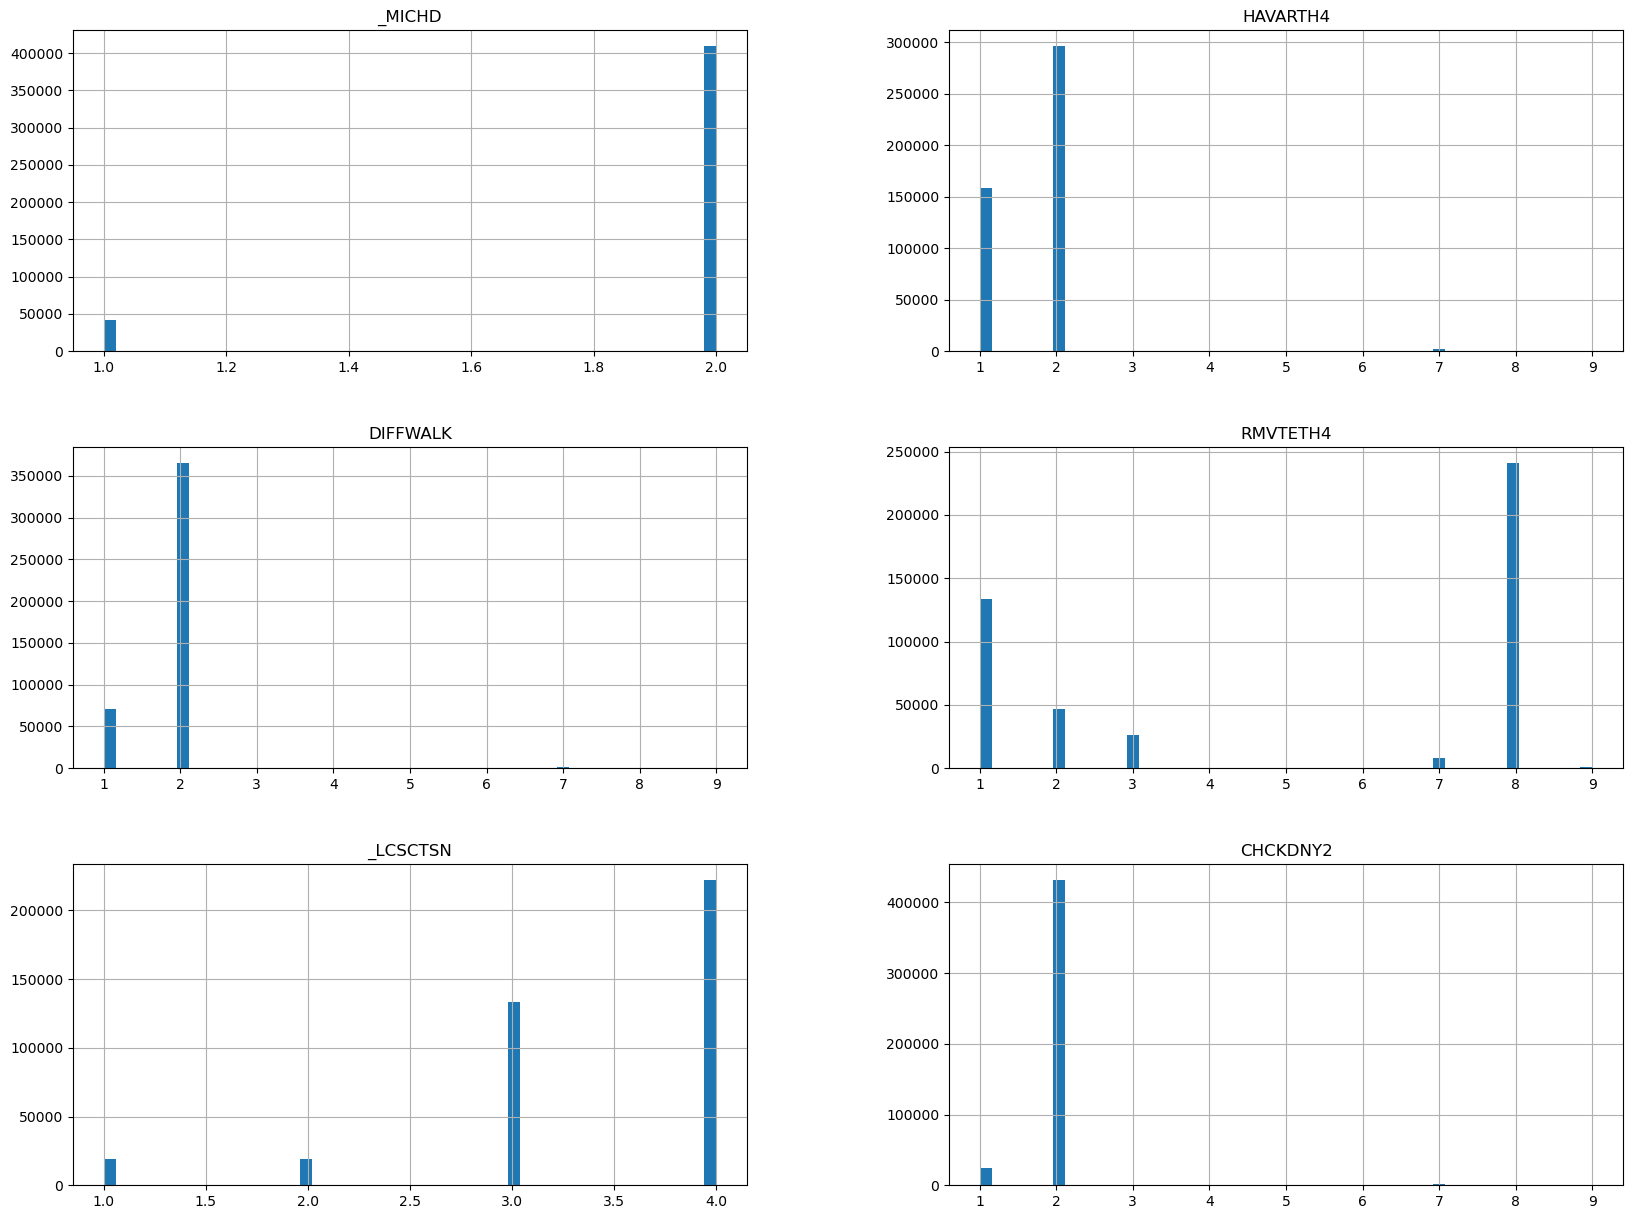

In [32]:
import matplotlib.pyplot as plt

dist = df[col]

dist.hist(bins=50, figsize=(20,15))
plt.show()